In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("C:/Users/rosha/OneDrive/Desktop/Fraud/data/creditcard.csv")
print("Data Load Successfully")

Data Load Successfully


In [4]:
print('Shape of Dataset : ',df.shape)

Shape of Dataset :  (284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


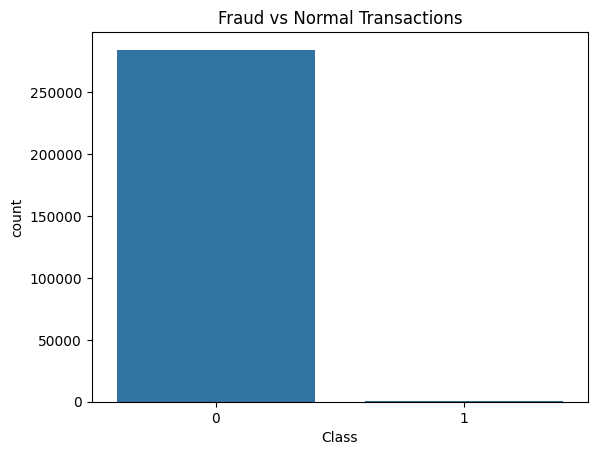

In [7]:
sns.countplot(x="Class",data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [8]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [9]:
x = df.drop("Class",axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
) 

print('Train shape :',X_train.shape)
print('Test shape : ',X_test.shape)

Train shape : (227845, 30)
Test shape :  (56962, 30)


In [10]:
#Logistic Regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression(max_iter=2000,class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [11]:


y_prob = pipeline.predict_proba(X_test)[:, 1]

# Try custom threshold
threshold = 0.9

y_custom = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_custom))
print(classification_report(y_test, y_custom))

[[56599   265]
 [   11    87]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.89      0.39        98

    accuracy                           1.00     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962



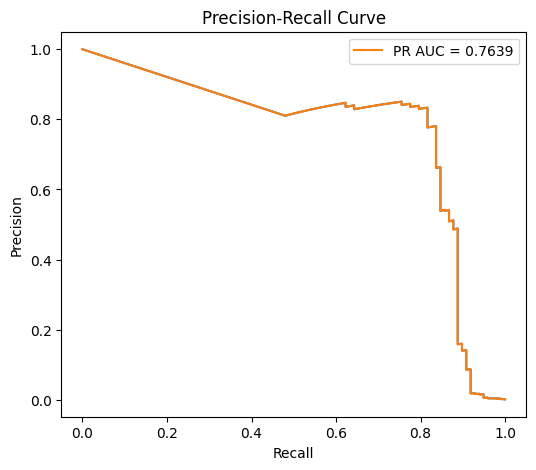

PR-AUC Score: 0.7638940554609512


In [14]:
from sklearn.metrics import precision_recall_curve, auc

y_prob = pipeline.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

pr_auc = auc(recall,precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("PR-AUC Score:", pr_auc)

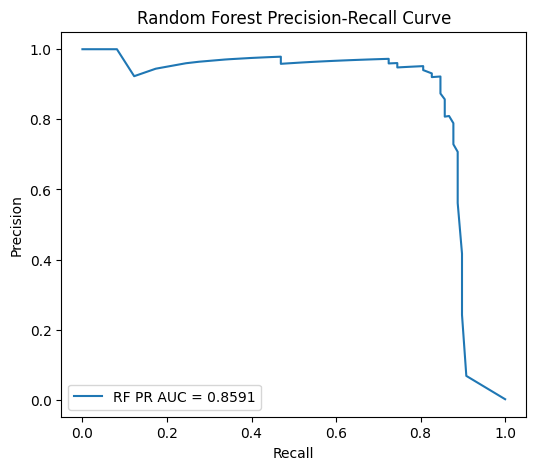

Random Forest PR-AUC: 0.8591141327761002


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf,precision_rf)

plt.figure(figsize=(6,5))
plt.plot(recall_rf, precision_rf, label=f"RF PR AUC = {pr_auc_rf:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.legend()
plt.show()

print("Random Forest PR-AUC:", pr_auc_rf)

c:\Users\rosha\anaconda3\envs\fraud_ml\lib\site-packages\xgboost\training.py:200: UserWarning: [09:17:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


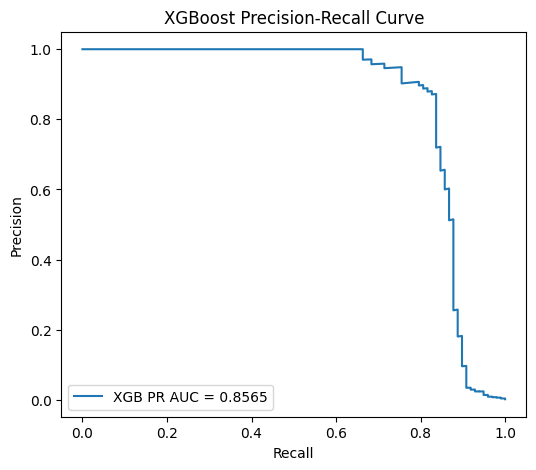

XGBoost PR-AUC: 0.8564978442252915


In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

plt.figure(figsize=(6,5))
plt.plot(recall_xgb, precision_xgb, label=f"XGB PR AUC = {pr_auc_xgb:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.legend()
plt.show()

print("XGBoost PR-AUC:", pr_auc_xgb)

In [ ]:
#Cost based threshold optimization using Random Forest probabilities

y_prob = y_prob_rf
y_true = y_test.values

# Define business costs
C_FN = 500   # cost of missing fraud
C_FP = 5     # cost of false alarm

thresholds = np.linspace(0.01, 0.99, 99)

best_t = None
best_cost = float("inf")
best_stats = None

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    FP = ((y_true == 0) & (y_pred == 1)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()

    cost = C_FP * FP + C_FN * FN

    if cost < best_cost:
        best_cost = cost
        best_t = t
        best_stats = (FP, FN)

print("Best threshold:", best_t)
print("Minimum cost:", best_cost)
print("False Positives, False Negatives:", best_stats)

Best threshold: 0.03
Minimum cost: 5615
False Positives, False Negatives: (np.int64(123), np.int64(10))


In [18]:
import joblib, json, os

os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(rf, "../models/random_forest.pkl")

# Save threshold + costs
config = {
    "threshold": float(best_t),   # should be 0.03
    "C_FN": 500,
    "C_FP": 5
}

with open("../models/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved successfully!")

Saved successfully!


In [19]:
fraud_rows = df[df["Class"]==1].index[:10]
fraud_rows


Index([541, 623, 4920, 6108, 6329, 6331, 6334, 6336, 6338, 6427], dtype='int64')